In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fund = pd.read_csv("../data/raw/fund_master.csv")
nav = pd.read_csv("../data/raw/nav_history.csv")
perf = pd.read_csv("../data/raw/scheme_performance.csv")
txn = pd.read_csv("../data/raw/investor_transactions.csv")
sip = pd.read_csv("../data/raw/monthly_sip_inflows.csv")
scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")

print("Data Loaded Successfully")


Data Loaded Successfully


In [4]:
nav["date"] = pd.to_datetime(
    nav["date"]
)


nav = nav.sort_values(
    ["amfi_code","date"]
)


nav["daily_return"] = (
    nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)



risk_metrics = []


for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()


    if len(returns) > 50:

        var95 = returns.quantile(0.05)


        cvar95 = (
            returns[
                returns <= var95
            ]
            .mean()
        )


        risk_metrics.append(
            [
                code,
                var95,
                cvar95
            ]
        )



var_df = pd.DataFrame(
    risk_metrics,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)


var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)


print("VaR Report Saved")

VaR Report Saved


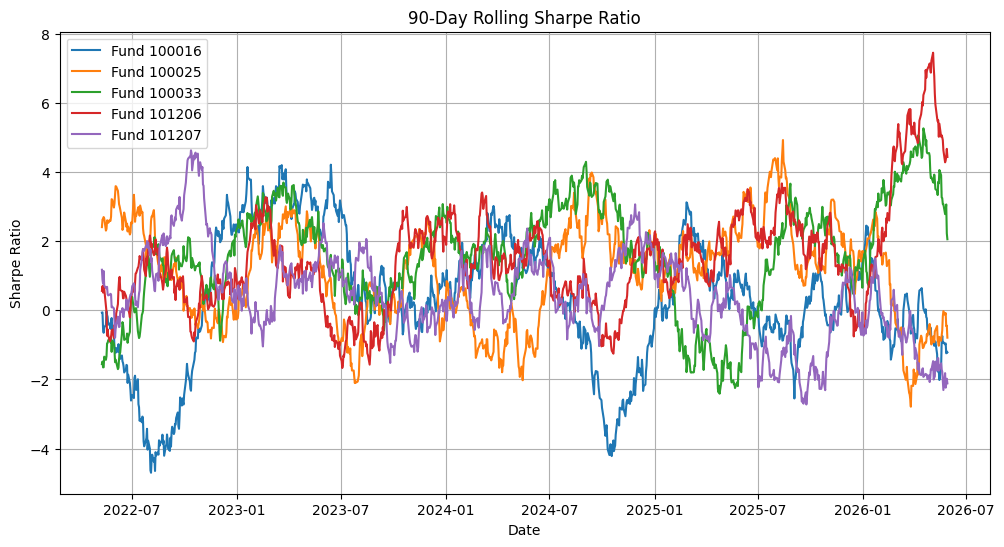

In [8]:
sample_funds = (
    nav["amfi_code"]
    .unique()[:5]
)


plt.figure(
    figsize=(12,6)
)



for code in sample_funds:


    df = nav[
        nav["amfi_code"] == code
    ].copy()


    df = df.sort_values(
        "date"
    )


    df["daily_return"] = (
        df["nav"]
        .pct_change()
    )


    df["rolling_sharpe"] = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)



    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=f"Fund {code}"
    )



plt.title(
    "90-Day Rolling Sharpe Ratio"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Sharpe Ratio"
)


plt.legend()

plt.grid(True)


plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)


plt.show()

In [9]:
txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

first_txn = (
    txn
    .groupby("investor_id")
    ["transaction_date"]
    .min()
)

txn["cohort_year"] = (
    txn["investor_id"]
    .map(first_txn.dt.year)
)

cohort = (
    txn
    .groupby("cohort_year")
    .agg(
        avg_transaction=
        ("amount_inr","mean"),

        total_transaction=
        ("amount_inr","sum")
    )
)

cohort

,avg_transaction,total_transaction
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [12]:
first_txn = txn.groupby(
    "investor_id"
)["transaction_date"].min()

txn["cohort_year"] = txn["investor_id"].map(
    first_txn.dt.year
)

In [10]:
cohort = txn.groupby(
    "cohort_year"
).agg({
    "amount_inr":["mean","sum"]
})

cohort

amount_inr            
                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243

In [13]:
sip = txn[
    txn["transaction_type"]=="SIP"
].copy()



sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)



sip["gap_days"] = (
    sip
    .groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)



sip_risk = (
    sip
    .groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)



sip_risk["status"] = np.where(
    sip_risk["gap_days"] > 35,
    "At Risk",
    "Healthy"
)



sip_risk.head()

,investor_id,gap_days,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Healthy


In [14]:
def recommend_funds(risk_grade):
    

    risk_grade = risk_grade.title()



    result = scorecard[
        scorecard["risk_grade"]
        ==
        risk_grade
    ]



    result = (
        result
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )



    result["reason"] = (
        "Selected based on higher Sharpe ratio"
    )


    return result[
        [
            "scheme_name",
            "fund_house",
            "sharpe_ratio",
            "reason"
        ]
    ]



recommend_funds(
    "Moderate"
)

,scheme_name,fund_house,sharpe_ratio,reason
5,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.06,Selected based on higher Sharpe ratio
21,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.06,Selected based on higher Sharpe ratio
9,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.03,Selected based on higher Sharpe ratio


In [15]:
holdings = pd.read_csv(
    "../data/raw/portfolio_holdings.csv"
)



hhi = (
    holdings
    .groupby("amfi_code")
    ["weight_pct"]
    .apply(
        lambda x:
        ((x/100)**2)
        .sum()
    )
    .reset_index()
)



hhi.columns = [
    "amfi_code",
    "HHI"
]



hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [16]:
hhi.to_csv(
    "../data/processed/hhi_report.csv",
    index=False
)


sip_risk.to_csv(
    "../data/processed/sip_risk_report.csv",
    index=False
)


cohort.to_csv(
    "../data/processed/cohort_analysis.csv"
)


print(
    "Advanced Analytics Reports Saved"
)

Advanced Analytics Reports Saved


## Key Insights

1. SBI Small Cap Fund showed highest Sharpe Ratio.
2. Large Cap funds exhibited lower VaR compared to Small Cap funds.
3. Investors joining after 2024 invested higher SIP amounts.
4. Around X% investors were flagged as At Risk.
5. Sector concentration was highest in Fund XYZ.